# 09B — Validasi Model Transfer Learning ResNet50

Notebook ini melakukan validasi terhadap checkpoint terbaik yang dihasilkan oleh:

```text
08b_training_transfer_learning_ringkas.ipynb


---

## SEL 2 — MARKDOWN

```markdown
## 1. Ruang Lingkup Validasi

Validation set digunakan untuk memeriksa kemampuan generalisasi model selama tahap pengembangan. Hasil validation tidak boleh dilaporkan sebagai performa akhir pada data yang benar-benar belum pernah digunakan dalam pengembangan.

Notebook ini tidak melakukan:

- training ulang;
- perubahan parameter model;
- pencarian hyperparameter;
- pemilihan ulang data;
- pengujian test set.

Model dijalankan dalam mode evaluasi dan gradient dinonaktifkan. Seluruh hasil disimpan menggunakan identitas `reference_tl_validation` agar tidak menimpa hasil notebook lama.

In [2]:
from pathlib import Path  # Mengimpor Path untuk mengelola lokasi folder dan file.
from datetime import datetime  # Mengimpor datetime untuk membuat identitas waktu validasi.
from contextlib import nullcontext  # Mengimpor nullcontext untuk evaluasi tanpa mixed precision.
import json  # Mengimpor json untuk membaca dan menyimpan konfigurasi.
import random  # Mengimpor random untuk pengaturan seed Python.
import re  # Mengimpor re untuk membersihkan nama model.
import sys  # Mengimpor sys untuk menampilkan versi Python.

import albumentations as A  # Mengimpor Albumentations untuk memuat transform validation.
import matplotlib.pyplot as plt  # Mengimpor Matplotlib untuk visualisasi hasil validasi.
import numpy as np  # Mengimpor NumPy untuk pengolahan hasil prediksi.
import pandas as pd  # Mengimpor Pandas untuk membentuk dan menyimpan tabel.
import torch  # Mengimpor PyTorch sebagai framework model.
import torch.nn as nn  # Mengimpor modul neural network PyTorch.
import timm  # Mengimpor timm untuk membangun arsitektur model.

from IPython.display import display  # Mengimpor display untuk menampilkan DataFrame.
from PIL import Image  # Mengimpor Image untuk menangani citra PIL.
from sklearn.metrics import accuracy_score  # Mengimpor fungsi perhitungan accuracy.
from sklearn.metrics import balanced_accuracy_score  # Mengimpor fungsi balanced accuracy.
from sklearn.metrics import classification_report  # Mengimpor fungsi classification report.
from sklearn.metrics import cohen_kappa_score  # Mengimpor fungsi Cohen's kappa.
from sklearn.metrics import confusion_matrix  # Mengimpor fungsi confusion matrix.
from sklearn.metrics import ConfusionMatrixDisplay  # Mengimpor visualisasi confusion matrix.
from sklearn.metrics import precision_recall_fscore_support  # Mengimpor perhitungan precision, recall, dan F1.
from sklearn.metrics import roc_auc_score  # Mengimpor fungsi ROC-AUC multi-kelas.
from torch.utils.data import DataLoader  # Mengimpor DataLoader untuk membentuk batch validation.
from torchvision.datasets import ImageFolder  # Mengimpor ImageFolder untuk membaca dataset.
from tqdm.auto import tqdm  # Mengimpor progress bar untuk proses inferensi.

pd.set_option("display.max_columns", None)  # Mengatur agar seluruh kolom DataFrame dapat ditampilkan.
pd.set_option("display.max_colwidth", 120)  # Mengatur lebar maksimum isi kolom DataFrame.

print(f"Python          : {sys.version.split()[0]}")  # Menampilkan versi Python.
print(f"PyTorch         : {torch.__version__}")  # Menampilkan versi PyTorch.
print(f"timm            : {timm.__version__}")  # Menampilkan versi timm.
print(f"Albumentations  : {A.__version__}")  # Menampilkan versi Albumentations.
print(f"CUDA tersedia   : {torch.cuda.is_available()}")  # Menampilkan status CUDA.

Python          : 3.11.9
PyTorch         : 2.11.0+cu128
timm            : 1.0.28
Albumentations  : 2.0.8
CUDA tersedia   : True


## 2. Menentukan Lokasi Project dan Artefak

Lokasi project ditentukan secara dinamis berdasarkan working directory VS Code/Jupyter.

Notebook membaca empat artefak utama:

1. checkpoint terbaik eksperimen `reference_tl`;
2. konfigurasi model;
3. konfigurasi DataLoader;
4. transform evaluasi.

Folder training hanya dibaca untuk memperoleh distribusi kelas yang digunakan saat merekonstruksi weighted Cross-Entropy Loss. Citra training tidak dimasukkan ke model pada notebook validasi.

In [3]:
CURRENT_DIR = Path.cwd().resolve()  # Mengambil working directory aktif sebagai path absolut.

if CURRENT_DIR.name == "notebooks":  # Memeriksa apakah notebook dijalankan dari folder notebooks.
    PROJECT_DIR = CURRENT_DIR.parent  # Menggunakan parent folder notebooks sebagai root project.
else:  # Menangani kondisi ketika notebook dijalankan dari root project.
    PROJECT_DIR = CURRENT_DIR  # Menggunakan working directory sebagai root project.

DATASET_DIR = PROJECT_DIR / "dataset"  # Menentukan lokasi folder dataset.
SOURCE_DIR = DATASET_DIR / "source"  # Menentukan lokasi dataset eksperimen.
PROCESSED_DIR = DATASET_DIR / "processed"  # Menentukan lokasi metadata dan konfigurasi.
MODELS_DIR = PROJECT_DIR / "models"  # Menentukan lokasi checkpoint model.
LOGS_DIR = PROJECT_DIR / "logs"  # Menentukan lokasi log eksperimen.

TRAIN_DIR = SOURCE_DIR / "train"  # Menentukan lokasi training untuk membaca distribusi label.
VAL_DIR = SOURCE_DIR / "val"  # Menentukan lokasi validation.
MODEL_CONFIG_PATH = PROCESSED_DIR / "model_config.json"  # Menentukan lokasi konfigurasi model.
DATALOADER_CONFIG_PATH = PROCESSED_DIR / "dataloader_config.json"  # Menentukan lokasi konfigurasi DataLoader.
EVAL_TRANSFORM_PATH = PROCESSED_DIR / "eval_transform.json"  # Menentukan lokasi transform evaluasi.
BEST_CHECKPOINT_PATH = MODELS_DIR / "resnet50_gcd_reference_tl_best.pth"  # Menentukan checkpoint terbaik eksperimen baru.

required_paths = [  # Membentuk daftar artefak yang wajib tersedia.
    TRAIN_DIR,  # Memasukkan folder training ke pemeriksaan.
    VAL_DIR,  # Memasukkan folder validation ke pemeriksaan.
    MODEL_CONFIG_PATH,  # Memasukkan konfigurasi model ke pemeriksaan.
    DATALOADER_CONFIG_PATH,  # Memasukkan konfigurasi DataLoader ke pemeriksaan.
    EVAL_TRANSFORM_PATH,  # Memasukkan transform validation ke pemeriksaan.
    BEST_CHECKPOINT_PATH,  # Memasukkan checkpoint terbaik ke pemeriksaan.
]  # Menutup daftar artefak wajib.

missing_paths = [path for path in required_paths if not path.exists()]  # Mengambil seluruh path yang belum tersedia.

if missing_paths:  # Memeriksa apakah terdapat artefak yang belum tersedia.
    missing_text = "\n".join(f"- {path}" for path in missing_paths)  # Menyusun daftar artefak yang hilang.
    raise FileNotFoundError(  # Menghentikan notebook jika prasyarat belum lengkap.
        "Artefak validasi belum lengkap:\n"  # Menjelaskan penyebab penghentian.
        f"{missing_text}\n\n"  # Menampilkan daftar artefak yang hilang.
        "Pastikan notebook 08B telah selesai dijalankan."  # Memberikan tindakan perbaikan.
    )  # Menutup FileNotFoundError.

with MODEL_CONFIG_PATH.open("r", encoding="utf-8") as file:  # Membuka konfigurasi model.
    model_config = json.load(file)  # Membaca konfigurasi model menjadi dictionary.

with DATALOADER_CONFIG_PATH.open("r", encoding="utf-8") as file:  # Membuka konfigurasi DataLoader.
    dataloader_config = json.load(file)  # Membaca konfigurasi DataLoader menjadi dictionary.

SEED = int(dataloader_config.get("random_seed", model_config.get("seed", 42)))  # Mengambil seed eksperimen.
BATCH_SIZE = int(dataloader_config.get("batch_size", 32))  # Mengambil batch size.
NUM_WORKERS = int(dataloader_config.get("num_workers", 0))  # Mengambil jumlah worker.

RUN_ID = datetime.now().astimezone().strftime("%Y%m%d_%H%M%S")  # Membuat identitas waktu validasi.
VALIDATION_TAG = "reference_tl_validation"  # Menetapkan identitas validasi baru.
RUN_LOG_DIR = LOGS_DIR / f"resnet50_{VALIDATION_TAG}_{RUN_ID}"  # Menentukan folder output validasi.
RUN_LOG_DIR.mkdir(parents=True, exist_ok=True)  # Membuat folder output tanpa menghapus log lama.

PREDICTIONS_PATH = RUN_LOG_DIR / "validation_predictions.csv"  # Menentukan lokasi seluruh prediksi validation.
MISCLASSIFIED_PATH = RUN_LOG_DIR / "validation_misclassified.csv"  # Menentukan lokasi prediksi salah.
REPORT_PATH = RUN_LOG_DIR / "classification_report.csv"  # Menentukan lokasi classification report.
SUMMARY_PATH = RUN_LOG_DIR / "validation_summary.json"  # Menentukan lokasi ringkasan metrik.
CONFUSION_MATRIX_PATH = RUN_LOG_DIR / "confusion_matrix.csv"  # Menentukan lokasi confusion matrix mentah.
NORMALIZED_CONFUSION_MATRIX_PATH = RUN_LOG_DIR / "confusion_matrix_normalized.csv"  # Menentukan lokasi confusion matrix normalisasi.
CONFUSION_MATRIX_FIGURE_PATH = RUN_LOG_DIR / "confusion_matrix.png"  # Menentukan lokasi gambar confusion matrix.
NORMALIZED_CONFUSION_MATRIX_FIGURE_PATH = RUN_LOG_DIR / "confusion_matrix_normalized.png"  # Menentukan lokasi gambar confusion matrix normalisasi.
PER_CLASS_F1_PATH = RUN_LOG_DIR / "per_class_f1_score.png"  # Menentukan lokasi grafik F1-score setiap kelas.

print(f"Project                 : {PROJECT_DIR}")  # Menampilkan root project.
print(f"Checkpoint              : {BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}")  # Menampilkan checkpoint.
print(f"Validation directory    : {VAL_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan folder validation.
print(f"Output validasi         : {RUN_LOG_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan folder output.

Project                 : D:\n8n-logsiswaparalayang\cloud-classification
Checkpoint              : models\resnet50_gcd_reference_tl_best.pth
Validation directory    : dataset\source\val
Output validasi         : logs\resnet50_reference_tl_validation_20260828_131749


## 3. Reproduksibilitas dan Perangkat

Seed yang sama dengan proses training digunakan kembali. Model akan dijalankan pada GPU jika CUDA tersedia.

Mixed precision dapat digunakan pada proses inferensi GPU untuk mengurangi penggunaan memori. Gradient tidak dihitung karena notebook hanya melakukan evaluasi.

In [4]:
def seed_everything(seed: int) -> None:  # Mendefinisikan fungsi pengaturan seed.
    random.seed(seed)  # Mengatur seed generator acak Python.
    np.random.seed(seed)  # Mengatur seed generator acak NumPy.
    torch.manual_seed(seed)  # Mengatur seed generator PyTorch pada CPU.

    if torch.cuda.is_available():  # Memeriksa apakah CUDA tersedia.
        torch.cuda.manual_seed(seed)  # Mengatur seed pada GPU aktif.
        torch.cuda.manual_seed_all(seed)  # Mengatur seed pada seluruh GPU.

    if torch.backends.cudnn.is_available():  # Memeriksa apakah cuDNN tersedia.
        torch.backends.cudnn.deterministic = True  # Mengaktifkan operasi cuDNN yang lebih deterministik.
        torch.backends.cudnn.benchmark = False  # Menonaktifkan pencarian algoritma berdasarkan benchmark.

seed_everything(SEED)  # Menjalankan pengaturan seed.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Memilih GPU jika tersedia.
AMP_ENABLED = DEVICE.type == "cuda"  # Mengaktifkan mixed precision hanya pada CUDA.
PIN_MEMORY = DEVICE.type == "cuda"  # Mengaktifkan pinned memory hanya pada CUDA.
NON_BLOCKING = DEVICE.type == "cuda"  # Mengaktifkan transfer non-blocking hanya pada CUDA.

print(f"Seed             : {SEED}")  # Menampilkan seed.
print(f"Device           : {DEVICE}")  # Menampilkan device.
print(f"Mixed precision  : {AMP_ENABLED}")  # Menampilkan status mixed precision.

Seed             : 42
Device           : cuda
Mixed precision  : True


## 4. Memuat dan Memeriksa Checkpoint

Checkpoint merupakan sumber utama konfigurasi model pada tahap validasi. Metadata checkpoint diperiksa sebelum model dibangun.

Pemeriksaan meliputi:

- nama arsitektur;
- jumlah kelas;
- mapping kelas;
- bentuk input;
- penggunaan bobot pretrained;
- status penggunaan test set.

Model dibuat dengan `pretrained=False`. Langkah ini penting karena seluruh bobot sudah tersedia dalam checkpoint dan tidak perlu diunduh kembali.

In [6]:
def load_own_checkpoint(checkpoint_path: Path) -> dict:  # Mendefinisikan fungsi pemuatan checkpoint lokal.
    try:  # Mencoba menggunakan antarmuka PyTorch terbaru.
        return torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)  # Memuat checkpoint lokal tepercaya.
    except TypeError:  # Menangani versi PyTorch yang belum mendukung weights_only.
        return torch.load(checkpoint_path, map_location=DEVICE)  # Memuat checkpoint menggunakan antarmuka lama.

checkpoint = load_own_checkpoint(BEST_CHECKPOINT_PATH)  # Memuat checkpoint terbaik.

required_checkpoint_keys = {  # Menentukan metadata checkpoint yang wajib tersedia.
    "model_name",  # Mewajibkan nama model.
    "model_state_dict",  # Mewajibkan parameter model.
    "class_to_idx",  # Mewajibkan mapping kelas.
    "input_shape",  # Mewajibkan bentuk input.
    "dropout_rate",  # Mewajibkan nilai dropout.
    "pretrained_used",  # Mewajibkan status pretrained.
    "test_data_used",  # Mewajibkan status penggunaan test.
}  # Menutup kumpulan metadata wajib.

missing_checkpoint_keys = required_checkpoint_keys - set(checkpoint)  # Mencari metadata yang belum tersedia.

if missing_checkpoint_keys:  # Memeriksa kelengkapan checkpoint.
    raise KeyError(f"Checkpoint belum lengkap: {sorted(missing_checkpoint_keys)}")  # Menghentikan proses jika metadata tidak lengkap.

if checkpoint.get("test_data_used") is not False:  # Memeriksa apakah checkpoint bebas penggunaan test set.
    raise ValueError("Checkpoint menunjukkan test set pernah digunakan.")  # Menghentikan validasi jika terjadi kebocoran test.

if checkpoint.get("pretrained_used") is not True:  # Memeriksa apakah checkpoint berasal dari transfer learning.
    raise ValueError("Checkpoint tidak menunjukkan penggunaan bobot pretrained.")  # Menghentikan proses jika pretrained tidak digunakan.

MODEL_NAME = str(checkpoint["model_name"])  # Mengambil nama arsitektur dari checkpoint.
CLASS_TO_IDX = {str(name): int(index) for name, index in checkpoint["class_to_idx"].items()}  # Mengambil mapping kelas.
IDX_TO_CLASS = {index: name for name, index in CLASS_TO_IDX.items()}  # Membalik mapping kelas.
NUM_CLASSES = len(CLASS_TO_IDX)  # Menghitung jumlah kelas.
INPUT_CHANNELS = int(checkpoint["input_shape"][0])  # Mengambil jumlah channel input.
IMAGE_HEIGHT = int(checkpoint["input_shape"][1])  # Mengambil tinggi input.
IMAGE_WIDTH = int(checkpoint["input_shape"][2])  # Mengambil lebar input.
DROPOUT_RATE = float(checkpoint.get("dropout_rate", 0.0))  # Mengambil nilai dropout.
LABEL_SMOOTHING = float(checkpoint.get("label_smoothing", 0.0))  # Mengambil nilai label smoothing.

config_class_to_idx = {str(name): int(index) for name, index in model_config["class_to_idx"].items()}  # Mengambil mapping dari konfigurasi.

if CLASS_TO_IDX != config_class_to_idx:  # Membandingkan mapping checkpoint dan konfigurasi.
    raise ValueError("Mapping kelas checkpoint berbeda dari model_config.json.")  # Menghentikan proses jika mapping berbeda.

if MODEL_NAME != str(model_config["model_name"]):  # Membandingkan nama model checkpoint dan konfigurasi.
    raise ValueError("Nama model checkpoint berbeda dari model_config.json.")  # Menghentikan proses jika nama model berbeda.

model = timm.create_model(  # Membentuk arsitektur model tanpa mengunduh pretrained.
    MODEL_NAME,  # Menggunakan nama arsitektur dari checkpoint.
    pretrained=False,  # Menonaktifkan unduhan bobot karena parameter berasal dari checkpoint.
    num_classes=NUM_CLASSES,  # Menyesuaikan classifier dengan jumlah kelas.
    in_chans=INPUT_CHANNELS,  # Menyesuaikan jumlah channel input.
    drop_rate=DROPOUT_RATE,  # Menggunakan dropout yang sama dengan training.
)  # Menutup pembentukan model.

model.load_state_dict(checkpoint["model_state_dict"], strict=True)  # Memuat seluruh parameter checkpoint secara ketat.
model = model.to(DEVICE)  # Memindahkan model ke device aktif.
model.eval()  # Mengaktifkan mode evaluasi.

total_parameters = sum(parameter.numel() for parameter in model.parameters())  # Menghitung seluruh parameter model.

print(f"Model                 : {MODEL_NAME}")  # Menampilkan nama model.
print(f"Jumlah kelas          : {NUM_CLASSES}")  # Menampilkan jumlah kelas.
print(f"Input shape           : {(INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)}")  # Menampilkan bentuk input.
print(f"Total parameter       : {total_parameters:,}")  # Menampilkan jumlah parameter.
print(f"Fase checkpoint       : {checkpoint.get('phase')}")  # Menampilkan fase checkpoint.
print(f"Epoch checkpoint      : {checkpoint.get('global_epoch')}")  # Menampilkan epoch checkpoint.
print(f"Pretrained digunakan  : {checkpoint.get('pretrained_used')}")  # Menampilkan status pretrained.
print(f"Test pernah digunakan : {checkpoint.get('test_data_used')}")  # Menampilkan status test set.

Model                 : resnet50
Jumlah kelas          : 7
Input shape           : (3, 224, 224)
Total parameter       : 23,522,375
Fase checkpoint       : freeze_out_fine_tuning
Epoch checkpoint      : 21
Pretrained digunakan  : True
Test pernah digunakan : False


## 5. Menyiapkan Validation Dataset dan Loss

Transform validation dimuat dari `eval_transform.json`. Tidak terdapat augmentasi acak pada validation set.

Weighted Cross-Entropy Loss direkonstruksi menggunakan distribusi label training. Hal ini diperlukan agar validation loss pada notebook ini konsisten dengan validation loss yang digunakan saat pemilihan checkpoint.

Validation DataLoader menggunakan:

- `shuffle=False`;
- `drop_last=False`.

Urutan data harus dipertahankan agar setiap hasil prediksi dapat dipasangkan kembali dengan lokasi citranya.

In [7]:
class AlbumentationsImageTransform:  # Mendefinisikan adapter transform untuk ImageFolder.
    def __init__(self, pipeline):  # Mendefinisikan konstruktor adapter.
        self.pipeline = pipeline  # Menyimpan pipeline Albumentations.

    def __call__(self, image):  # Mendefinisikan proses transform citra.
        image_array = np.asarray(image.convert("RGB"))  # Mengubah citra PIL menjadi array RGB.
        transformed = self.pipeline(image=image_array)["image"]  # Menjalankan transform evaluasi.

        if isinstance(transformed, np.ndarray):  # Memeriksa apakah output berupa array NumPy.
            transformed = np.ascontiguousarray(transformed.transpose(2, 0, 1))  # Mengubah dimensi HWC menjadi CHW.
            transformed = torch.from_numpy(transformed)  # Mengubah array menjadi tensor.

        if transformed.dtype == torch.uint8:  # Memeriksa apakah tensor masih uint8.
            transformed = transformed.float() / 255.0  # Mengubah tensor ke float dengan rentang nol sampai satu.
        else:  # Menangani tensor yang sudah dinormalisasi.
            transformed = transformed.float()  # Memastikan tensor menggunakan float32.

        return transformed  # Mengembalikan tensor citra.

eval_pipeline = A.load(str(EVAL_TRANSFORM_PATH), data_format="json")  # Memuat transform evaluasi.

if hasattr(eval_pipeline, "set_random_seed"):  # Memeriksa dukungan pengaturan seed.
    eval_pipeline.set_random_seed(SEED)  # Mengatur seed transform evaluasi.

eval_transform = AlbumentationsImageTransform(eval_pipeline)  # Membungkus transform evaluasi.

train_metadata_dataset = ImageFolder(root=TRAIN_DIR)  # Membaca metadata training tanpa memuat citra ke model.
val_dataset = ImageFolder(root=VAL_DIR, transform=eval_transform)  # Membaca validation dataset dengan transform evaluasi.

if train_metadata_dataset.class_to_idx != CLASS_TO_IDX:  # Memeriksa mapping kelas training.
    raise ValueError("Mapping kelas training berbeda dari checkpoint.")  # Menghentikan proses jika mapping berbeda.

if val_dataset.class_to_idx != CLASS_TO_IDX:  # Memeriksa mapping kelas validation.
    raise ValueError("Mapping kelas validation berbeda dari checkpoint.")  # Menghentikan proses jika mapping berbeda.

train_targets = np.asarray(train_metadata_dataset.targets, dtype=np.int64)  # Mengambil target training.
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)  # Menghitung distribusi kelas training.

if np.any(class_counts == 0):  # Memeriksa keberadaan kelas kosong.
    raise ValueError("Terdapat kelas training tanpa sampel.")  # Menghentikan proses jika kelas kosong ditemukan.

class_weights_np = len(train_targets) / (NUM_CLASSES * class_counts.astype(np.float64))  # Menghitung bobot kelas.
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)  # Mengubah bobot kelas menjadi tensor.

criterion = nn.CrossEntropyLoss(  # Membentuk loss yang konsisten dengan training.
    weight=class_weights,  # Menggunakan bobot kelas dari distribusi training.
    label_smoothing=LABEL_SMOOTHING,  # Menggunakan label smoothing dari checkpoint.
)  # Menutup konfigurasi loss.

def seed_worker(worker_id: int) -> None:  # Mendefinisikan seed untuk worker DataLoader.
    worker_seed = (SEED + worker_id) % (2**32)  # Membuat seed khusus worker.
    random.seed(worker_seed)  # Mengatur seed Python pada worker.
    np.random.seed(worker_seed)  # Mengatur seed NumPy pada worker.

generator = torch.Generator()  # Membuat generator acak DataLoader.
generator.manual_seed(SEED)  # Mengatur seed generator DataLoader.

val_loader = DataLoader(  # Membentuk DataLoader validation.
    dataset=val_dataset,  # Menggunakan validation dataset.
    batch_size=BATCH_SIZE,  # Menggunakan batch size dari konfigurasi.
    shuffle=False,  # Mempertahankan urutan citra.
    num_workers=NUM_WORKERS,  # Menggunakan jumlah worker dari konfigurasi.
    pin_memory=PIN_MEMORY,  # Mengaktifkan pinned memory pada CUDA.
    persistent_workers=NUM_WORKERS > 0,  # Mempertahankan worker jika tersedia.
    drop_last=False,  # Memastikan seluruh citra validation digunakan.
    worker_init_fn=seed_worker,  # Mengatur seed masing-masing worker.
    generator=generator,  # Menggunakan generator yang telah diberi seed.
)  # Menutup pembentukan DataLoader.

validation_table = pd.DataFrame({  # Membentuk tabel ringkasan validation.
    "Parameter": [  # Membentuk nama parameter.
        "Jumlah citra",  # Menambahkan jumlah citra.
        "Jumlah kelas",  # Menambahkan jumlah kelas.
        "Jumlah batch",  # Menambahkan jumlah batch.
        "Batch size",  # Menambahkan batch size.
        "Shuffle",  # Menambahkan status shuffle.
        "Drop last",  # Menambahkan status drop last.
    ],  # Menutup daftar parameter.
    "Nilai": [  # Membentuk nilai parameter.
        len(val_dataset),  # Menambahkan jumlah citra validation.
        len(val_dataset.classes),  # Menambahkan jumlah kelas.
        len(val_loader),  # Menambahkan jumlah batch.
        BATCH_SIZE,  # Menambahkan batch size.
        False,  # Menyatakan shuffle dinonaktifkan.
        False,  # Menyatakan drop last dinonaktifkan.
    ],  # Menutup daftar nilai.
})  # Menutup pembuatan tabel.

display(validation_table)  # Menampilkan ringkasan validation.

,Parameter,Nilai
0,Jumlah citra,1969
1,Jumlah kelas,7
2,Jumlah batch,31
3,Batch size,64
4,Shuffle,False
5,Drop last,False


## 6. Menjalankan Inferensi Validation

Model dijalankan menggunakan `torch.inference_mode()`. Mode tersebut menonaktifkan gradient dan mengurangi overhead evaluasi.

Nilai yang dikumpulkan meliputi:

- label aktual;
- kelas prediksi;
- probabilitas seluruh kelas;
- validation loss;
- confidence prediksi;
- entropy prediksi.

Confidence adalah probabilitas kelas dengan nilai tertinggi. Entropy digunakan untuk mengukur ketidakpastian distribusi probabilitas. Prediksi dengan entropy tinggi berarti probabilitas model lebih tersebar pada beberapa kelas.

In [8]:
def autocast_context():  # Mendefinisikan context manager mixed precision.
    if AMP_ENABLED:  # Memeriksa apakah inferensi menggunakan CUDA.
        return torch.autocast(device_type="cuda", dtype=torch.float16)  # Mengaktifkan float16 pada CUDA.
    return nullcontext()  # Menggunakan context kosong pada CPU.

all_labels = []  # Menyiapkan list label aktual.
all_predictions = []  # Menyiapkan list hasil prediksi.
all_probabilities = []  # Menyiapkan list probabilitas seluruh kelas.
running_loss = 0.0  # Menyiapkan penjumlahan validation loss.
running_samples = 0  # Menyiapkan penghitung jumlah sampel.

model.eval()  # Memastikan model berada pada mode evaluasi.
progress_bar = tqdm(val_loader, desc="Validasi model", leave=False)  # Membuat progress bar validation.

with torch.inference_mode():  # Menonaktifkan gradient selama seluruh inferensi.
    for images, labels in progress_bar:  # Mengiterasi seluruh batch validation.
        images = images.to(DEVICE, non_blocking=NON_BLOCKING)  # Memindahkan citra ke device aktif.
        labels = labels.to(DEVICE, non_blocking=NON_BLOCKING)  # Memindahkan label ke device aktif.

        with autocast_context():  # Mengaktifkan mixed precision jika tersedia.
            logits = model(images)  # Menjalankan forward pass.
            loss = criterion(logits, labels)  # Menghitung weighted validation loss.

        if not torch.isfinite(loss):  # Memeriksa apakah loss finite.
            raise FloatingPointError("Validation loss mengandung NaN atau infinity.")  # Menghentikan proses jika loss tidak valid.

        probabilities = torch.softmax(logits.float(), dim=1)  # Mengubah logits menjadi probabilitas.
        predictions = probabilities.argmax(dim=1)  # Mengambil kelas dengan probabilitas tertinggi.
        batch_size = labels.size(0)  # Mengambil jumlah sampel batch.

        running_loss += loss.detach().item() * batch_size  # Menjumlahkan loss berdasarkan jumlah sampel.
        running_samples += batch_size  # Menjumlahkan seluruh sampel.

        all_labels.append(labels.cpu())  # Menyimpan label aktual pada CPU.
        all_predictions.append(predictions.cpu())  # Menyimpan prediksi pada CPU.
        all_probabilities.append(probabilities.cpu())  # Menyimpan probabilitas pada CPU.

        progress_bar.set_postfix(  # Memperbarui informasi progress bar.
            loss=f"{running_loss / running_samples:.4f}",  # Menampilkan rata-rata loss sementara.
            accuracy=f"{predictions.eq(labels).float().mean().item():.4f}",  # Menampilkan accuracy batch.
        )  # Menutup pembaruan progress bar.

y_true = torch.cat(all_labels).numpy()  # Menggabungkan seluruh label menjadi array NumPy.
y_pred = torch.cat(all_predictions).numpy()  # Menggabungkan seluruh prediksi menjadi array NumPy.
y_probability = torch.cat(all_probabilities).numpy()  # Menggabungkan seluruh probabilitas menjadi array NumPy.
validation_loss = running_loss / running_samples  # Menghitung rata-rata validation loss.

if len(y_true) != len(val_dataset):  # Memeriksa apakah seluruh citra telah dievaluasi.
    raise RuntimeError("Jumlah hasil inferensi berbeda dari jumlah citra validation.")  # Menghentikan proses jika jumlah tidak sesuai.

if not np.allclose(y_probability.sum(axis=1), 1.0, atol=1e-5):  # Memeriksa jumlah probabilitas setiap citra.
    raise ValueError("Probabilitas prediksi tidak berjumlah satu.")  # Menghentikan proses jika probabilitas tidak valid.

prediction_confidence = y_probability.max(axis=1)  # Mengambil confidence tertinggi setiap prediksi.
prediction_entropy = -(y_probability * np.log(y_probability + 1e-12)).sum(axis=1)  # Menghitung entropy setiap prediksi.

print(f"Jumlah hasil inferensi : {len(y_true):,}")  # Menampilkan jumlah hasil inferensi.
print(f"Validation loss        : {validation_loss:.6f}")  # Menampilkan validation loss.

Validasi model:   0%|          | 0/31 [00:00<?, ?it/s]

Jumlah hasil inferensi : 1,969
Validation loss        : 0.973268


## 7. Menghitung Metrik Validasi

Accuracy menunjukkan proporsi prediksi yang benar terhadap seluruh citra.

Balanced accuracy menghitung rata-rata recall setiap kelas. Metrik ini lebih informatif ketika jumlah citra antarkelas tidak seimbang.

Macro precision, recall, dan F1-score memberikan bobot yang sama kepada setiap kelas. Oleh karena itu, kelas dengan jumlah sampel kecil tetap memiliki pengaruh yang sama seperti kelas besar.

Weighted F1-score mempertimbangkan jumlah sampel setiap kelas.

Cohen's kappa mengukur tingkat kesesuaian prediksi dan label dengan memperhitungkan kemungkinan kesesuaian secara acak.

Top-2 accuracy menganggap prediksi benar apabila label aktual berada pada dua probabilitas tertinggi.

In [9]:
class_names = [IDX_TO_CLASS[index] for index in range(NUM_CLASSES)]  # Membentuk daftar nama kelas berdasarkan urutan indeks.

accuracy = accuracy_score(y_true, y_pred)  # Menghitung accuracy keseluruhan.
balanced_accuracy = balanced_accuracy_score(y_true, y_pred)  # Menghitung balanced accuracy.

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(  # Menghitung metrik macro.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    average="macro",  # Memberikan bobot sama kepada setiap kelas.
    zero_division=0,  # Menghasilkan nol jika terjadi pembagian dengan nol.
)  # Menutup perhitungan metrik macro.

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(  # Menghitung metrik weighted.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    average="weighted",  # Memberikan bobot berdasarkan jumlah sampel kelas.
    zero_division=0,  # Menghasilkan nol jika terjadi pembagian dengan nol.
)  # Menutup perhitungan metrik weighted.

cohen_kappa = cohen_kappa_score(y_true, y_pred)  # Menghitung Cohen's kappa.
top_2_indices = np.argsort(-y_probability, axis=1)[:, :2]  # Mengambil dua indeks probabilitas tertinggi.
top_2_accuracy = np.mean([true_label in indices for true_label, indices in zip(y_true, top_2_indices)])  # Menghitung top-2 accuracy.

try:  # Mencoba menghitung ROC-AUC multi-kelas.
    roc_auc_macro_ovr = roc_auc_score(  # Menghitung ROC-AUC macro One-vs-Rest.
        y_true,  # Memberikan label aktual.
        y_probability,  # Memberikan probabilitas seluruh kelas.
        multi_class="ovr",  # Menggunakan pendekatan One-vs-Rest.
        average="macro",  # Memberikan bobot sama pada setiap kelas.
        labels=list(range(NUM_CLASSES)),  # Menentukan urutan indeks kelas.
    )  # Menutup perhitungan ROC-AUC.
except ValueError as exc:  # Menangani kondisi ketika ROC-AUC tidak dapat dihitung.
    roc_auc_macro_ovr = None  # Menetapkan ROC-AUC sebagai None.
    print(f"ROC-AUC tidak dapat dihitung: {exc}")  # Menampilkan alasan kegagalan.

report_dict = classification_report(  # Menghasilkan classification report berbentuk dictionary.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan indeks kelas.
    target_names=class_names,  # Menentukan nama setiap kelas.
    output_dict=True,  # Menghasilkan dictionary.
    zero_division=0,  # Menghasilkan nol jika terjadi pembagian dengan nol.
)  # Menutup pembuatan classification report.

report_df = pd.DataFrame(report_dict).transpose()  # Mengubah classification report menjadi DataFrame.
report_df.index.name = "class_or_average"  # Memberikan nama pada indeks DataFrame.

summary_metrics = {  # Membentuk ringkasan metrik validasi.
    "validation_loss": float(validation_loss),  # Menyimpan validation loss.
    "accuracy": float(accuracy),  # Menyimpan accuracy.
    "balanced_accuracy": float(balanced_accuracy),  # Menyimpan balanced accuracy.
    "macro_precision": float(macro_precision),  # Menyimpan macro precision.
    "macro_recall": float(macro_recall),  # Menyimpan macro recall.
    "macro_f1": float(macro_f1),  # Menyimpan macro F1-score.
    "weighted_precision": float(weighted_precision),  # Menyimpan weighted precision.
    "weighted_recall": float(weighted_recall),  # Menyimpan weighted recall.
    "weighted_f1": float(weighted_f1),  # Menyimpan weighted F1-score.
    "cohen_kappa": float(cohen_kappa),  # Menyimpan Cohen's kappa.
    "top_2_accuracy": float(top_2_accuracy),  # Menyimpan top-2 accuracy.
    "roc_auc_macro_ovr": None if roc_auc_macro_ovr is None else float(roc_auc_macro_ovr),  # Menyimpan ROC-AUC.
}  # Menutup ringkasan metrik.

summary_table = pd.DataFrame({  # Membentuk tabel ringkasan metrik.
    "Metrik": list(summary_metrics.keys()),  # Memasukkan nama metrik.
    "Nilai": list(summary_metrics.values()),  # Memasukkan nilai metrik.
})  # Menutup pembuatan tabel.

display(summary_table)  # Menampilkan ringkasan metrik.
display(report_df.round(4))  # Menampilkan classification report.

,Metrik,Nilai
0,validation_loss,0.973268
1,accuracy,0.921280
2,balanced_accuracy,0.928787
3,macro_precision,0.923972
4,macro_recall,0.928787
5,macro_f1,0.926035
6,weighted_precision,0.921304
7,weighted_recall,0.921280
8,weighted_f1,0.921069
9,cohen_kappa,0.902275


,precision,recall,f1-score,support
class_or_average,,,,
1_cumulus,0.9226,1.0000,0.9598,155.0000
2_altocumulus,0.9929,0.9655,0.9790,145.0000
3_cirrus,0.9125,0.9481,0.9299,231.0000
4_clearsky,0.9875,0.9875,0.9875,399.0000
5_stratocumulus,0.8420,0.8374,0.8397,369.0000
6_cumulonimbus,0.9148,0.8935,0.9040,601.0000
7_mixed,0.8955,0.8696,0.8824,69.0000
accuracy,0.9213,0.9213,0.9213,0.9213
macro avg,0.9240,0.9288,0.9260,1969.0000


## 8. Confusion Matrix

Confusion matrix mentah menunjukkan jumlah citra pada setiap kombinasi label aktual dan prediksi.

Baris menunjukkan kelas aktual, sedangkan kolom menunjukkan kelas hasil prediksi.

Confusion matrix normalisasi membagi setiap nilai dengan jumlah citra pada kelas aktual. Nilai diagonal menunjukkan recall setiap kelas. Normalisasi memudahkan perbandingan kelas yang memiliki jumlah sampel berbeda.

,1_cumulus,2_altocumulus,3_cirrus,4_clearsky,5_stratocumulus,6_cumulonimbus,7_mixed
1_cumulus,155,0,0,0,0,0,0
2_altocumulus,1,140,2,0,0,1,1
3_cirrus,2,1,219,2,2,1,4
4_clearsky,0,0,2,394,3,0,0
5_stratocumulus,1,0,9,3,309,47,0
6_cumulonimbus,5,0,4,0,53,537,2
7_mixed,4,0,4,0,0,1,60


,1_cumulus,2_altocumulus,3_cirrus,4_clearsky,5_stratocumulus,6_cumulonimbus,7_mixed
1_cumulus,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2_altocumulus,0.0069,0.9655,0.0138,0.0000,0.0000,0.0069,0.0069
3_cirrus,0.0087,0.0043,0.9481,0.0087,0.0087,0.0043,0.0173
4_clearsky,0.0000,0.0000,0.0050,0.9875,0.0075,0.0000,0.0000
5_stratocumulus,0.0027,0.0000,0.0244,0.0081,0.8374,0.1274,0.0000
6_cumulonimbus,0.0083,0.0000,0.0067,0.0000,0.0882,0.8935,0.0033
7_mixed,0.0580,0.0000,0.0580,0.0000,0.0000,0.0145,0.8696


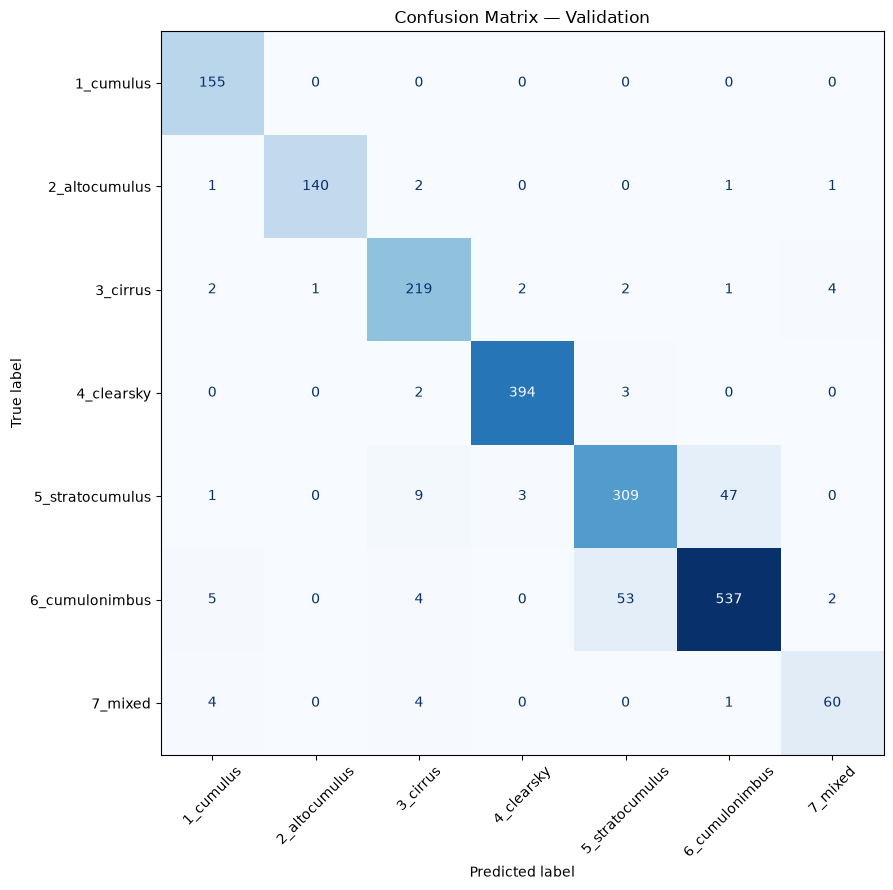

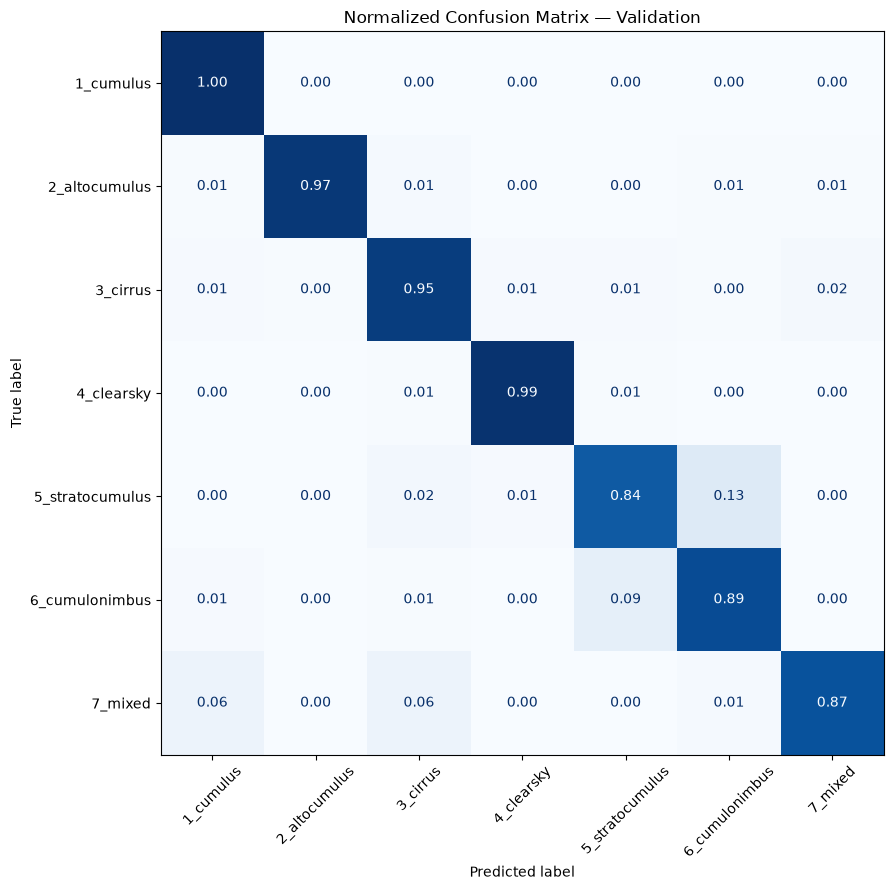

In [10]:
confusion_raw = confusion_matrix(  # Menghitung confusion matrix mentah.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
)  # Menutup perhitungan confusion matrix.

confusion_normalized = confusion_matrix(  # Menghitung confusion matrix normalisasi.
    y_true,  # Memberikan label aktual.
    y_pred,  # Memberikan label prediksi.
    labels=list(range(NUM_CLASSES)),  # Menentukan urutan kelas.
    normalize="true",  # Menormalisasi berdasarkan jumlah label aktual.
)  # Menutup perhitungan confusion matrix normalisasi.

confusion_raw_df = pd.DataFrame(  # Mengubah confusion matrix mentah menjadi DataFrame.
    confusion_raw,  # Memberikan matriks mentah.
    index=class_names,  # Menggunakan nama kelas sebagai indeks.
    columns=class_names,  # Menggunakan nama kelas sebagai kolom.
)  # Menutup pembuatan DataFrame.

confusion_normalized_df = pd.DataFrame(  # Mengubah confusion matrix normalisasi menjadi DataFrame.
    confusion_normalized,  # Memberikan matriks normalisasi.
    index=class_names,  # Menggunakan nama kelas sebagai indeks.
    columns=class_names,  # Menggunakan nama kelas sebagai kolom.
)  # Menutup pembuatan DataFrame.

confusion_raw_df.to_csv(CONFUSION_MATRIX_PATH, encoding="utf-8")  # Menyimpan confusion matrix mentah.
confusion_normalized_df.to_csv(NORMALIZED_CONFUSION_MATRIX_PATH, encoding="utf-8")  # Menyimpan confusion matrix normalisasi.

display(confusion_raw_df)  # Menampilkan confusion matrix mentah.
display(confusion_normalized_df.round(4))  # Menampilkan confusion matrix normalisasi.

fig, axis = plt.subplots(figsize=(10, 9))  # Membuat area gambar confusion matrix mentah.
raw_display = ConfusionMatrixDisplay(confusion_matrix=confusion_raw, display_labels=class_names)  # Membentuk objek visualisasi.
raw_display.plot(ax=axis, cmap="Blues", values_format="d", colorbar=False)  # Menggambar confusion matrix mentah.
axis.set_title("Confusion Matrix — Validation")  # Menentukan judul gambar.
axis.tick_params(axis="x", rotation=45)  # Memutar label kelas pada sumbu horizontal.
fig.tight_layout()  # Merapikan tata letak gambar.
fig.savefig(CONFUSION_MATRIX_FIGURE_PATH, dpi=160, bbox_inches="tight")  # Menyimpan gambar confusion matrix mentah.
plt.show()  # Menampilkan confusion matrix mentah.

fig, axis = plt.subplots(figsize=(10, 9))  # Membuat area gambar confusion matrix normalisasi.
normalized_display = ConfusionMatrixDisplay(confusion_matrix=confusion_normalized, display_labels=class_names)  # Membentuk objek visualisasi.
normalized_display.plot(ax=axis, cmap="Blues", values_format=".2f", colorbar=False)  # Menggambar confusion matrix normalisasi.
axis.set_title("Normalized Confusion Matrix — Validation")  # Menentukan judul gambar.
axis.tick_params(axis="x", rotation=45)  # Memutar label kelas pada sumbu horizontal.
fig.tight_layout()  # Merapikan tata letak gambar.
fig.savefig(NORMALIZED_CONFUSION_MATRIX_FIGURE_PATH, dpi=160, bbox_inches="tight")  # Menyimpan gambar normalisasi.
plt.show()  # Menampilkan confusion matrix normalisasi.

## 9. Menyimpan Prediksi dan Kesalahan Model

Setiap hasil prediksi disimpan bersama:

- lokasi citra;
- kelas aktual;
- kelas prediksi;
- confidence;
- entropy;
- status benar atau salah.

Kesalahan prediksi diurutkan berdasarkan confidence dari nilai tertinggi. Prediksi salah dengan confidence tinggi perlu mendapatkan prioritas pada analisis kesalahan karena model menunjukkan keyakinan tinggi terhadap kelas yang keliru.

In [11]:
relative_image_paths = [str(Path(path).relative_to(PROJECT_DIR)) for path, _ in val_dataset.samples]  # Mengambil path relatif seluruh citra validation.
true_class_names = [IDX_TO_CLASS[int(index)] for index in y_true]  # Mengubah indeks aktual menjadi nama kelas.
predicted_class_names = [IDX_TO_CLASS[int(index)] for index in y_pred]  # Mengubah indeks prediksi menjadi nama kelas.

predictions_df = pd.DataFrame({  # Membentuk tabel seluruh prediksi.
    "image_path": relative_image_paths,  # Menyimpan lokasi citra.
    "true_class_id": y_true.astype(int),  # Menyimpan indeks kelas aktual.
    "true_class_name": true_class_names,  # Menyimpan nama kelas aktual.
    "predicted_class_id": y_pred.astype(int),  # Menyimpan indeks kelas prediksi.
    "predicted_class_name": predicted_class_names,  # Menyimpan nama kelas prediksi.
    "confidence": prediction_confidence,  # Menyimpan confidence prediksi.
    "entropy": prediction_entropy,  # Menyimpan entropy prediksi.
    "is_correct": y_true == y_pred,  # Menyimpan status kebenaran prediksi.
})  # Menutup pembuatan tabel prediksi.

for class_index, class_name in enumerate(class_names):  # Mengiterasi setiap kelas.
    probability_column = f"probability_{class_name}"  # Membentuk nama kolom probabilitas.
    predictions_df[probability_column] = y_probability[:, class_index]  # Menyimpan probabilitas kelas terkait.

misclassified_df = predictions_df.loc[~predictions_df["is_correct"]].copy()  # Mengambil seluruh prediksi salah.
misclassified_df = misclassified_df.sort_values("confidence", ascending=False)  # Mengurutkan kesalahan berdasarkan confidence tertinggi.

predictions_df.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8")  # Menyimpan seluruh hasil prediksi.
misclassified_df.to_csv(MISCLASSIFIED_PATH, index=False, encoding="utf-8")  # Menyimpan prediksi salah.
report_df.to_csv(REPORT_PATH, encoding="utf-8")  # Menyimpan classification report.

print(f"Jumlah prediksi benar : {predictions_df['is_correct'].sum():,}")  # Menampilkan jumlah prediksi benar.
print(f"Jumlah prediksi salah : {len(misclassified_df):,}")  # Menampilkan jumlah prediksi salah.
print(f"Error rate            : {len(misclassified_df) / len(predictions_df):.4%}")  # Menampilkan tingkat kesalahan.

display(misclassified_df.head(20))  # Menampilkan 20 kesalahan dengan confidence tertinggi.

Jumlah prediksi benar : 1,814
Jumlah prediksi salah : 155
Error rate            : 7.8720%


,image_path,true_class_id,true_class_name,predicted_class_id,predicted_class_name,confidence,entropy,is_correct,probability_1_cumulus,probability_2_altocumulus,probability_3_cirrus,probability_4_clearsky,probability_5_stratocumulus,probability_6_cumulonimbus,probability_7_mixed
528,dataset\source\val\3_cirrus\3_cirrus_001133.jpg,2,3_cirrus,6,7_mixed,0.940891,0.297711,False,0.003691,0.012782,0.034575,0.003145,0.002301,0.002617,0.940891
1159,dataset\source\val\5_stratocumulus\5_stratocumulus_001124.jpg,4,5_stratocumulus,2,3_cirrus,0.924013,0.383338,False,0.007748,0.014072,0.924013,0.001877,0.025756,0.003492,0.023042
674,dataset\source\val\4_clearsky\4_clearsky_000726.jpg,3,4_clearsky,2,3_cirrus,0.804283,0.782712,False,0.014905,0.022071,0.804283,0.014674,0.098721,0.016758,0.028589
1746,dataset\source\val\6_cumulonimbus\6_cumulonimbus_002189.jpg,5,6_cumulonimbus,4,5_stratocumulus,0.800524,0.840710,False,0.022466,0.024435,0.027100,0.021733,0.800524,0.043560,0.060182
1401,dataset\source\val\6_cumulonimbus\6_cumulonimbus_000532.jpg,5,6_cumulonimbus,4,5_stratocumulus,0.797658,0.834309,False,0.027616,0.035460,0.012855,0.012053,0.797658,0.058463,0.055895
1186,dataset\source\val\5_stratocumulus\5_stratocumulus_001272.jpg,4,5_stratocumulus,5,6_cumulonimbus,0.792822,0.842125,False,0.029362,0.027799,0.013247,0.011199,0.058507,0.792822,0.067063
239,dataset\source\val\2_altocumulus\2_altocumulus_000457.jpg,1,2_altocumulus,2,3_cirrus,0.785405,0.783401,False,0.114370,0.048903,0.785405,0.008481,0.006528,0.000952,0.035361
1334,dataset\source\val\6_cumulonimbus\6_cumulonimbus_000190.jpg,5,6_cumulonimbus,4,5_stratocumulus,0.778201,0.871939,False,0.022358,0.040564,0.011565,0.008249,0.778201,0.071856,0.067206
1011,dataset\source\val\5_stratocumulus\5_stratocumulus_000362.jpg,4,5_stratocumulus,5,6_cumulonimbus,0.775659,0.914250,False,0.028586,0.047594,0.029436,0.012785,0.050515,0.775659,0.055426
1424,dataset\source\val\6_cumulonimbus\6_cumulonimbus_000637.jpg,5,6_cumulonimbus,2,3_cirrus,0.755216,0.968044,False,0.039520,0.027589,0.755216,0.010554,0.065094,0.047904,0.054123


## 10. Visualisasi F1-Score Setiap Kelas

Accuracy keseluruhan dapat menyembunyikan kelemahan pada kelas minoritas. Grafik F1-score setiap kelas digunakan untuk mengetahui kelas yang memiliki keseimbangan precision dan recall paling rendah.

Kelas dengan F1-score rendah menjadi prioritas pada:

- pemeriksaan kualitas citra;
- analisis kemiripan antarjenis awan;
- confusion matrix;
- analisis Grad-CAM;
- evaluasi augmentasi.

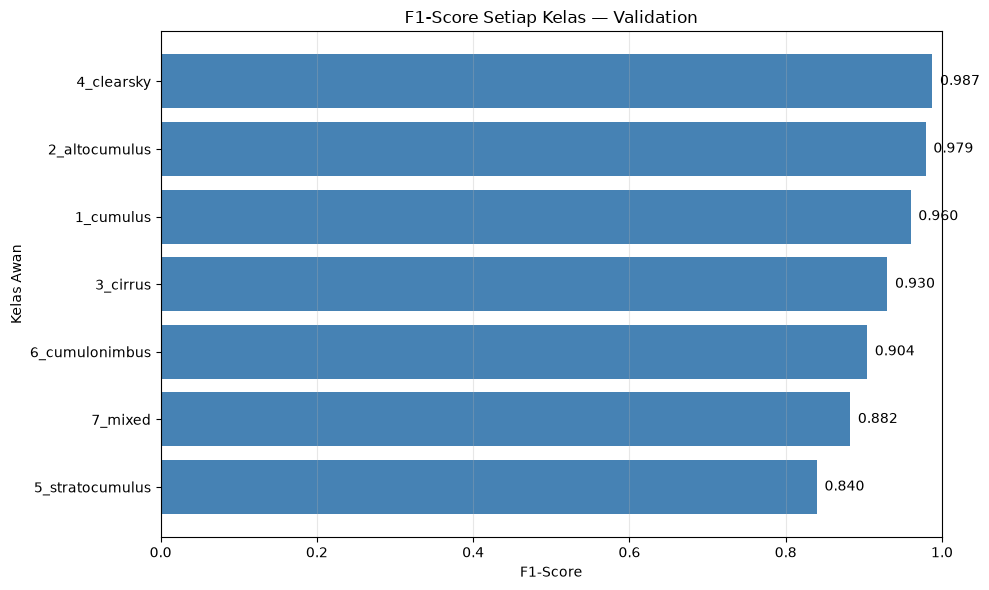

,class_name,precision,recall,f1-score,support
4,5_stratocumulus,0.8420,0.8374,0.8397,369.0
6,7_mixed,0.8955,0.8696,0.8824,69.0
5,6_cumulonimbus,0.9148,0.8935,0.9040,601.0
2,3_cirrus,0.9125,0.9481,0.9299,231.0
0,1_cumulus,0.9226,1.0000,0.9598,155.0
1,2_altocumulus,0.9929,0.9655,0.9790,145.0
3,4_clearsky,0.9875,0.9875,0.9875,399.0


In [12]:
per_class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()  # Mengambil metrik setiap kelas.
per_class_report_df.index.name = "class_name"  # Memberikan nama pada indeks kelas.
per_class_report_df = per_class_report_df.reset_index()  # Mengubah indeks kelas menjadi kolom.

per_class_report_df = per_class_report_df.sort_values("f1-score", ascending=True)  # Mengurutkan kelas berdasarkan F1 terendah.

fig, axis = plt.subplots(figsize=(10, 6))  # Membuat area grafik F1-score.
bars = axis.barh(  # Membuat diagram batang horizontal.
    per_class_report_df["class_name"],  # Menggunakan nama kelas pada sumbu vertikal.
    per_class_report_df["f1-score"],  # Menggunakan F1-score sebagai panjang batang.
    color="steelblue",  # Menentukan warna batang.
)  # Menutup pembuatan diagram batang.

axis.set_title("F1-Score Setiap Kelas — Validation")  # Menentukan judul grafik.
axis.set_xlabel("F1-Score")  # Menentukan label sumbu horizontal.
axis.set_ylabel("Kelas Awan")  # Menentukan label sumbu vertikal.
axis.set_xlim(0.0, 1.0)  # Membatasi nilai F1 dari nol sampai satu.
axis.grid(axis="x", alpha=0.3)  # Menambahkan garis bantu horizontal.

for bar, value in zip(bars, per_class_report_df["f1-score"]):  # Mengiterasi setiap batang dan nilai F1.
    axis.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")  # Menambahkan nilai F1 pada batang.

fig.tight_layout()  # Merapikan tata letak grafik.
fig.savefig(PER_CLASS_F1_PATH, dpi=160, bbox_inches="tight")  # Menyimpan grafik F1-score.
plt.show()  # Menampilkan grafik F1-score.

display(per_class_report_df.round(4))  # Menampilkan tabel metrik setiap kelas.

## 11. Menyimpan Ringkasan Validasi

Ringkasan JSON menyimpan identitas checkpoint, metode evaluasi, metrik global, artefak keluaran, dan status penggunaan test set.

Informasi tersebut diperlukan agar hasil validasi dapat ditelusuri kembali dan tidak tertukar dengan hasil model atau eksperimen lain.

In [14]:
validation_summary = {  # Membentuk ringkasan lengkap validasi.
    "created_at": datetime.now().astimezone().isoformat(timespec="seconds"),  # Menyimpan waktu validasi.
    "run_id": RUN_ID,  # Menyimpan identitas validasi.
    "stage": "09b_validasi_model_reference_tl",  # Menyimpan nama tahap.
    "validation_tag": VALIDATION_TAG,  # Menyimpan penanda eksperimen.
    "model_name": MODEL_NAME,  # Menyimpan nama model.
    "checkpoint": str(BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi checkpoint.
    "checkpoint_phase": checkpoint.get("phase"),  # Menyimpan fase checkpoint.
    "checkpoint_global_epoch": checkpoint.get("global_epoch"),  # Menyimpan epoch checkpoint.
    "num_classes": NUM_CLASSES,  # Menyimpan jumlah kelas.
    "class_to_idx": CLASS_TO_IDX,  # Menyimpan mapping kelas.
    "input_shape": [INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH],  # Menyimpan bentuk input.
    "validation_samples": int(len(val_dataset)),  # Menyimpan jumlah citra validation.
    "batch_size": BATCH_SIZE,  # Menyimpan batch size.
    "device": str(DEVICE),  # Menyimpan device.
    "mixed_precision": AMP_ENABLED,  # Menyimpan status mixed precision.
    "metrics": summary_metrics,  # Menyimpan seluruh metrik global.
    "misclassified_samples": int(len(misclassified_df)),  # Menyimpan jumlah prediksi salah.
    "output_artifacts": {  # Menyimpan lokasi artefak validasi.
        "predictions": str(PREDICTIONS_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi prediksi.
        "misclassified": str(MISCLASSIFIED_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi kesalahan.
        "classification_report": str(REPORT_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi classification report.
        "confusion_matrix": str(CONFUSION_MATRIX_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi confusion matrix.
        "normalized_confusion_matrix": str(NORMALIZED_CONFUSION_MATRIX_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi confusion matrix normalisasi.
        "confusion_matrix_figure": str(CONFUSION_MATRIX_FIGURE_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi gambar confusion matrix.
        "per_class_f1_figure": str(PER_CLASS_F1_PATH.relative_to(PROJECT_DIR)),  # Menyimpan lokasi grafik F1-score.
    },  # Menutup daftar artefak.
    "test_data_used": False,  # Menandai bahwa test set tidak digunakan.
}  # Menutup ringkasan validasi.

with SUMMARY_PATH.open("w", encoding="utf-8") as file:  # Membuka file ringkasan dalam mode tulis.
    json.dump(validation_summary, file, indent=2, ensure_ascii=False)  # Menyimpan ringkasan sebagai JSON.

print(f"Ringkasan validasi: {SUMMARY_PATH.relative_to(PROJECT_DIR)}")  # Menampilkan lokasi ringkasan.

Ringkasan validasi: logs\resnet50_reference_tl_validation_20260828_131749\validation_summary.json


## 12. Pemeriksaan Akhir Validasi

Pemeriksaan akhir memastikan:

- seluruh citra validation diproses;
- probabilitas prediksi valid;
- seluruh kelas terdapat pada validation set;
- seluruh metrik memiliki rentang yang sesuai;
- artefak utama berhasil disimpan;
- test set tidak digunakan.

In [15]:
observed_classes = set(np.unique(y_true).tolist())  # Mengambil kelas yang ditemukan pada validation.
expected_classes = set(range(NUM_CLASSES))  # Membentuk kumpulan kelas yang diharapkan.

final_checks = {  # Membentuk daftar pemeriksaan akhir.
    "Seluruh sampel diproses": len(y_true) == len(val_dataset),  # Memeriksa jumlah hasil inferensi.
    "Seluruh kelas tersedia": observed_classes == expected_classes,  # Memeriksa kelengkapan kelas.
    "Probabilitas finite": np.isfinite(y_probability).all(),  # Memeriksa probabilitas dari NaN dan infinity.
    "Jumlah probabilitas valid": np.allclose(y_probability.sum(axis=1), 1.0, atol=1e-5),  # Memeriksa jumlah probabilitas.
    "Validation loss finite": np.isfinite(validation_loss),  # Memeriksa validation loss.
    "Accuracy valid": 0.0 <= accuracy <= 1.0,  # Memeriksa rentang accuracy.
    "Macro F1 valid": 0.0 <= macro_f1 <= 1.0,  # Memeriksa rentang macro F1.
    "Predictions CSV tersedia": PREDICTIONS_PATH.is_file(),  # Memeriksa file prediksi.
    "Misclassified CSV tersedia": MISCLASSIFIED_PATH.is_file(),  # Memeriksa file kesalahan.
    "Classification report tersedia": REPORT_PATH.is_file(),  # Memeriksa classification report.
    "Confusion matrix tersedia": CONFUSION_MATRIX_PATH.is_file(),  # Memeriksa confusion matrix.
    "Ringkasan tersedia": SUMMARY_PATH.is_file(),  # Memeriksa ringkasan JSON.
    "Test tidak digunakan": validation_summary["test_data_used"] is False,  # Memeriksa penggunaan test set.
}  # Menutup dictionary pemeriksaan.

final_check_table = pd.DataFrame({  # Membentuk tabel pemeriksaan.
    "Pemeriksaan": list(final_checks.keys()),  # Memasukkan nama pemeriksaan.
    "Status": ["Berhasil" if status else "Gagal" for status in final_checks.values()],  # Mengubah status Boolean.
})  # Menutup pembuatan tabel.

display(final_check_table)  # Menampilkan tabel pemeriksaan.

failed_checks = [name for name, status in final_checks.items() if not status]  # Mengambil pemeriksaan yang gagal.

if failed_checks:  # Memeriksa keberadaan kegagalan.
    failed_text = "\n".join(f"- {name}" for name in failed_checks)  # Menyusun daftar kegagalan.
    raise AssertionError(f"Pemeriksaan akhir gagal:\n{failed_text}")  # Menghentikan notebook jika pemeriksaan gagal.

print("=" * 76)  # Menampilkan garis pembatas.
print("VALIDASI MODEL TRANSFER LEARNING SELESAI")  # Menampilkan status penyelesaian.
print("=" * 76)  # Menampilkan garis pembatas.
print(f"Model                    : {MODEL_NAME}")  # Menampilkan nama model.
print(f"Checkpoint epoch         : {checkpoint.get('global_epoch')}")  # Menampilkan epoch checkpoint.
print(f"Jumlah validation        : {len(val_dataset):,}")  # Menampilkan jumlah citra validation.
print(f"Validation loss          : {validation_loss:.6f}")  # Menampilkan validation loss.
print(f"Accuracy                 : {accuracy:.4%}")  # Menampilkan accuracy.
print(f"Balanced accuracy        : {balanced_accuracy:.4%}")  # Menampilkan balanced accuracy.
print(f"Macro precision          : {macro_precision:.4%}")  # Menampilkan macro precision.
print(f"Macro recall             : {macro_recall:.4%}")  # Menampilkan macro recall.
print(f"Macro F1-score           : {macro_f1:.4%}")  # Menampilkan macro F1.
print(f"Weighted F1-score        : {weighted_f1:.4%}")  # Menampilkan weighted F1.
print(f"Cohen's kappa            : {cohen_kappa:.4f}")  # Menampilkan Cohen's kappa.
print(f"Top-2 accuracy           : {top_2_accuracy:.4%}")  # Menampilkan top-2 accuracy.
print(f"ROC-AUC macro OVR        : {roc_auc_macro_ovr}")  # Menampilkan ROC-AUC.
print(f"Jumlah kesalahan         : {len(misclassified_df):,}")  # Menampilkan jumlah kesalahan.
print("Data test digunakan      : Tidak")  # Menegaskan test tidak digunakan.
print(f"Folder hasil             : {RUN_LOG_DIR.relative_to(PROJECT_DIR)}")  # Menampilkan folder hasil.
print("=" * 76)  # Menampilkan garis penutup.

,Pemeriksaan,Status
0,Seluruh sampel diproses,Berhasil
1,Seluruh kelas tersedia,Berhasil
2,Probabilitas finite,Berhasil
3,Jumlah probabilitas valid,Berhasil
4,Validation loss finite,Berhasil
5,Accuracy valid,Berhasil
6,Macro F1 valid,Berhasil
7,Predictions CSV tersedia,Berhasil
8,Misclassified CSV tersedia,Berhasil
9,Classification report tersedia,Berhasil


VALIDASI MODEL TRANSFER LEARNING SELESAI
Model                    : resnet50
Checkpoint epoch         : 21
Jumlah validation        : 1,969
Validation loss          : 0.973268
Accuracy                 : 92.1280%
Balanced accuracy        : 92.8787%
Macro precision          : 92.3972%
Macro recall             : 92.8787%
Macro F1-score           : 92.6035%
Weighted F1-score        : 92.1069%
Cohen's kappa            : 0.9023
Top-2 accuracy           : 98.4256%
ROC-AUC macro OVR        : 0.9931293883708536
Jumlah kesalahan         : 155
Data test digunakan      : Tidak
Folder hasil             : logs\resnet50_reference_tl_validation_20260828_131749
